In [34]:
# CELL 1: Imports et chargement des donnees pretraitees

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des jeux pretraites (issus de l'etape 2)
X_train = pd.read_csv('./data/output/X_train_prep.csv')
X_test = pd.read_csv('./data/output/X_test_prep.csv')
# squeeze() : conversion des cibles (une seule colonne) en Series
y_train = pd.read_csv('./data/output/y_train.csv').squeeze()
y_test = pd.read_csv('./data/output/y_test.csv').squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (111280, 66) | X_test: (27820, 66)
y_train: (111280,) | y_test: (27820,)


## Prediction a un jours

In [35]:
# CELL 2: Entrainement des trois modeles (gestion du desequilibre)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Ratio de desequilibre pour XGBoost : negatifs / positifs (calcule sur le train)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

# Trois modeles, chacun avec sa gestion du desequilibre de classes
modeles = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                             random_state=42, n_jobs=-1),
}

# Entrainement puis prediction (labels + probabilites) sur le jeu de test
predictions = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    y_proba = modele.predict_proba(X_test)[:, 1]
    predictions[nom] = {'y_pred': y_pred, 'y_proba': y_proba}
    print(f"{nom} : entraine.")

scale_pos_weight = 3.4849
LogisticRegression : entraine.
RandomForest : entraine.
XGBoost : entraine.


In [36]:
# CELL 3: Tableau comparatif des performances

from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

# Metriques sur le jeu de test (F1 = metrique principale car classes desequilibrees)
lignes = []
for nom in modeles:
    y_pred = predictions[nom]['y_pred']
    y_proba = predictions[nom]['y_proba']
    lignes.append({
        'Modele': nom,
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
    })

comparaison = pd.DataFrame(lignes).sort_values('F1', ascending=False).reset_index(drop=True)
print("Comparaison des performances (jeu de test), triee par F1 decroissant:")
print(comparaison.round(4).to_string(index=False))

Comparaison des performances (jeu de test), triee par F1 decroissant:
            Modele     F1  ROC_AUC  Precision  Recall  Accuracy
           XGBoost 0.6504   0.8863     0.5670  0.7627    0.8172
LogisticRegression 0.6107   0.8580     0.5110  0.7587    0.7843
      RandomForest 0.5972   0.8842     0.7817  0.4832    0.8547


Figure sauvegardee: figures/etape3_01_matrices_confusion.png


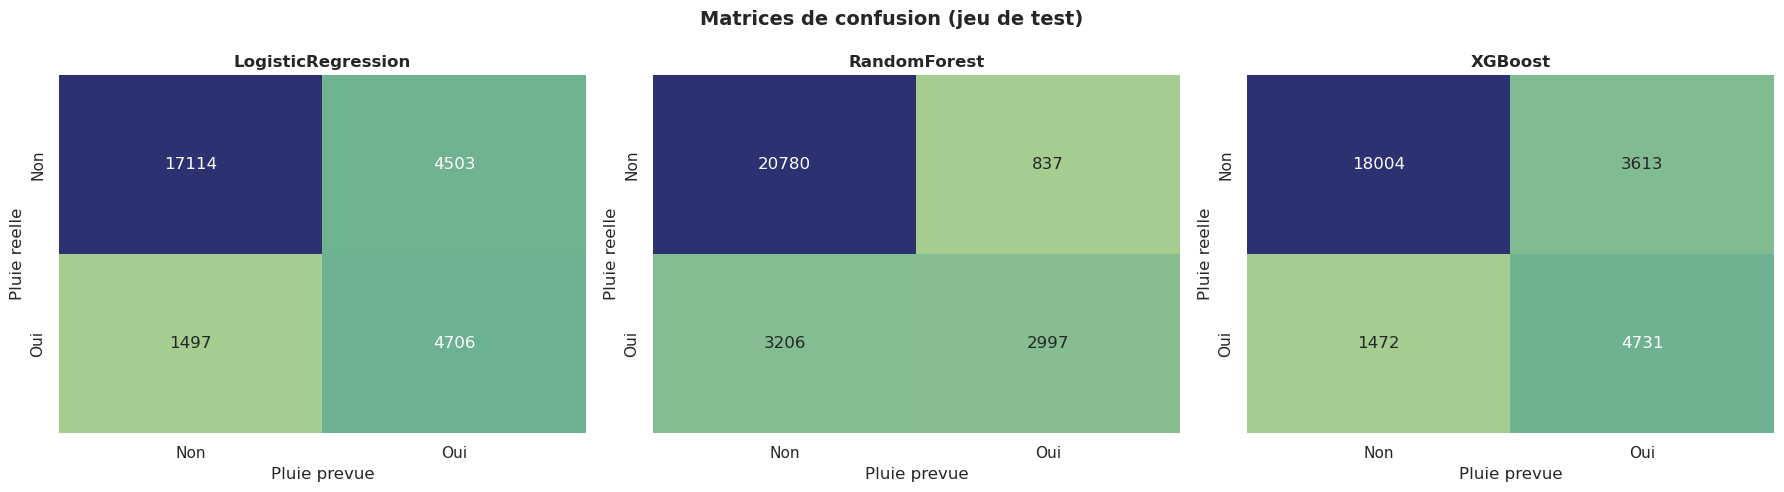

In [37]:
# CELL 4: Matrices de confusion

from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nom in zip(axes, modeles):
    cm = confusion_matrix(y_test, predictions[nom]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', cbar=False, ax=ax)
    ax.set_title(nom, fontsize=12, fontweight='bold')
    ax.set_xlabel("Pluie prevue")
    ax.set_ylabel("Pluie reelle")
    ax.set_xticklabels(['Non', 'Oui'])
    ax.set_yticklabels(['Non', 'Oui'])

fig.suptitle("Matrices de confusion (jeu de test)", fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig('../figures/etape3_01_matrices_confusion.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape3_01_matrices_confusion.png")
plt.show()

Figure sauvegardee: figures/etape3_02_courbes_roc.png


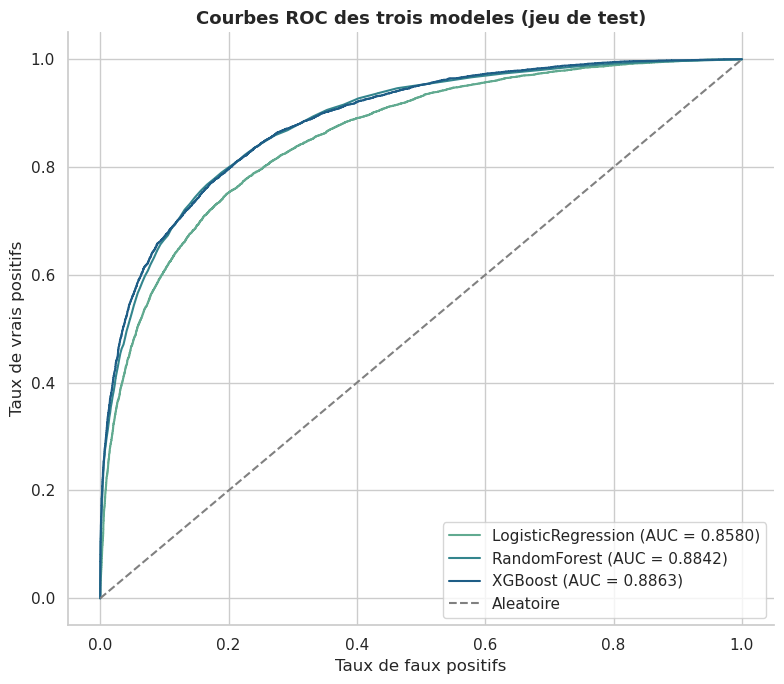

In [38]:
# CELL 5: Courbes ROC superposees
from sklearn.metrics import roc_curve

sns.set_theme(style="whitegrid", context="notebook")
couleurs = sns.color_palette("crest", len(modeles))

fig, ax = plt.subplots(figsize=(8, 7))
for nom, couleur in zip(modeles, couleurs):
    y_proba = predictions[nom]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=couleur, label=f"{nom} (AUC = {auc:.4f})")

# Ligne de reference du classifieur aleatoire
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatoire')
ax.set_title("Courbes ROC des trois modeles (jeu de test)", fontsize=13, fontweight='bold')
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
fig.savefig('../figures/etape3_02_courbes_roc.png', dpi=150, bbox_inches='tight')
print("Figure sauvegardee: figures/etape3_02_courbes_roc.png")
plt.show()

## Save model pour prediction a un jour

In [39]:
# CELL 6: Sauvegarde des trois modeles entraines

import joblib
import os


logreg = modeles['LogisticRegression']
rf = modeles['RandomForest']
xgb_model = modeles['XGBoost']

# Creation du dossier models/ a la racine du projet si necessaire
os.makedirs('../models', exist_ok=True)

# Sauvegarde : joblib pour les modeles sklearn, format natif JSON pour XGBoost
joblib.dump(logreg, '../models/logreg.joblib')
joblib.dump(rf, '../models/random_forest.joblib')
xgb_model.save_model('../models/xgboost.json')

print("Modeles sauvegardes:")
print(" - models/logreg.joblib")
print(" - models/random_forest.joblib")
print(" - models/xgboost.json")

Modeles sauvegardes:
 - models/logreg.joblib
 - models/random_forest.joblib
 - models/xgboost.json


# Analyse de l'effet du reechantillonnage

In [40]:
# CELL 8: Comparaison des strategies de reechantillonnage
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

In [41]:
# Ratio de desequilibre pour XGBoost : negatifs / positifs (calcule sur le train)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
#print(f"scale_pos_weight = {scale_pos_weight:.4f}")

# Trois modeles, chacun avec sa gestion du desequilibre de classes / l'option balanced a ete supprimee
modeles = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier( random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=1, eval_metric='logloss',
                             random_state=42, n_jobs=-1),
}


strategies_samplings = {
    'Sans reechantillonnage': None,
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42), #Combine over- and under-sampling using SMOTE and Tomek links
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
}


results = []
# Loop for the sampling method:
for strategie,sampler in strategies_samplings.items():

    #select the sampler 
    if sampler is None:
        X_train_sampling  = X_train.copy()
        y_train_sampling  = y_train.copy()
    else:
        X_train_sampling , y_train_sampling = sampler.fit_resample(X_train, y_train)

# Entrainement puis prediction (labels + probabilites) sur le jeu de test
    predictions = {}
    for nom, modele in modeles.items():
        modele.fit(X_train_sampling, y_train_sampling)
        y_pred = modele.predict(X_test)
        y_proba = modele.predict_proba(X_test)[:, 1]
        predictions[nom] = {'y_pred': y_pred, 'y_proba': y_proba}
        #print(f"{nom} : entraine.")

        results.append({
        'Strategie': strategie,   
        'Modele': nom,
        'F1': f1_score(y_test, y_pred),
        'ROC_AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
            })

        

In [42]:
df_results = pd.DataFrame(results)

reference = comparaison[['Modele', 'F1', 'ROC_AUC', 'Precision', 'Recall']].copy()
reference['Strategie'] = 'Baseline ponderee'

comparaison_results= pd.concat([
    reference[['Strategie', 'Modele', 'F1', 'ROC_AUC', 'Precision', 'Recall']],
    df_results,
], ignore_index=True)


In [43]:
comparaison_results

,Strategie,Modele,F1,ROC_AUC,Precision,Recall
0,Baseline ponderee,XGBoost,0.650443,0.886307,0.566994,0.762695
1,Baseline ponderee,LogisticRegression,0.610693,0.857961,0.511022,0.758665
2,Baseline ponderee,RandomForest,0.597190,0.884161,0.781690,0.483153
3,Sans reechantillonnage,LogisticRegression,0.580932,0.857363,0.725779,0.484282
4,Sans reechantillonnage,RandomForest,0.609725,0.882802,0.775510,0.502338
5,Sans reechantillonnage,XGBoost,0.647396,0.889854,0.757838,0.565049
6,RandomOverSampler,LogisticRegression,0.611043,0.857864,0.511292,0.759149
7,RandomOverSampler,RandomForest,0.648084,0.886224,0.718321,0.590360
8,RandomOverSampler,XGBoost,0.656718,0.887107,0.576600,0.762695
9,SMOTE,LogisticRegression,0.584044,0.830985,0.577554,0.590682


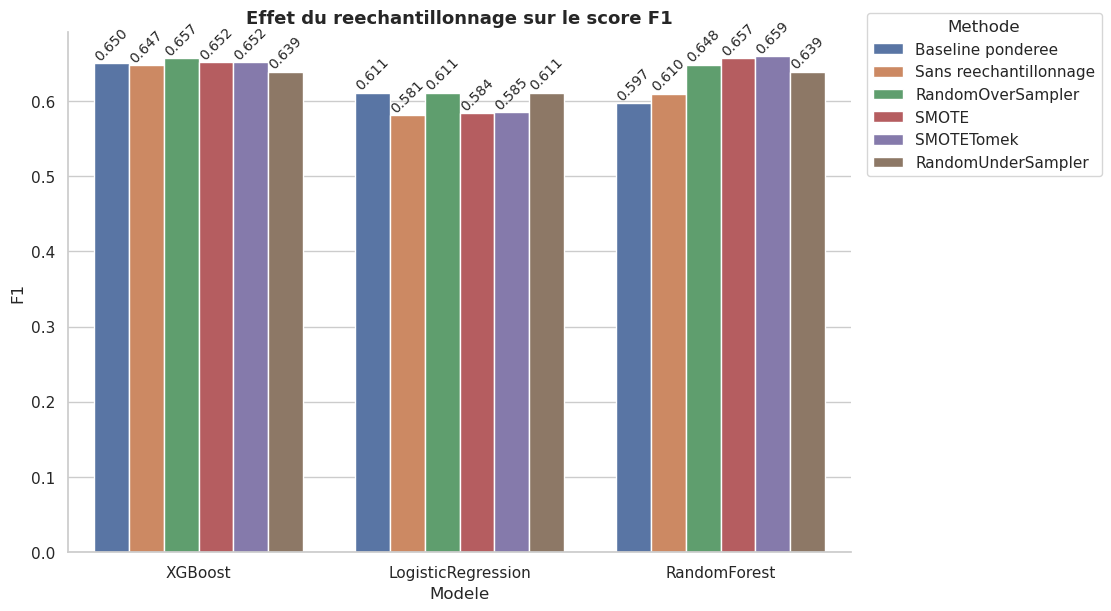

In [44]:
#sns.set_theme(style="whitegrid", context="notebook")
fig, ax = plt.subplots(figsize=(11, 6), layout='constrained')
sns.barplot(data=comparaison_results, x='Modele', y='F1', hue='Strategie', ax=ax)
ax.set_title("Effet du reechantillonnage sur le score F1", fontsize=13, fontweight='bold')
ax.set_xlabel("Modele")
ax.set_ylabel("F1")

for container in ax.containers:
    ax.bar_label(container, fontsize=10, rotation=45, fmt='{:.3f}',label_type='edge')
ax.legend(title="Methode",bbox_to_anchor=(1.01, 1.05))

sns.despine()
#plt.tight_layout()
#fig.savefig('../figures/etape3_03_effet_reechantillonnage.png', dpi=150, bbox_inches='tight')
#print("\nFigure sauvegardee: figures/etape3_03_effet_reechantillonnage.png")
plt.show()

## Prediction a deux jours

In [45]:
y_train2 = pd.read_csv('./data/output/y_train2.csv').squeeze()
y_test2 = pd.read_csv('./data/output/y_test2.csv').squeeze()

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (111280, 66) | X_test: (27820, 66)
y_train: (111280,) | y_test: (27820,)


In [46]:
# Ratio de desequilibre pour XGBoost : negatifs / positifs (calcule sur le train)
scale_pos_weight = (y_train2 == 0).sum() / (y_train2 == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.4f}")

# Trois modeles, chacun avec sa gestion du desequilibre de classes
modeles = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                             random_state=42, n_jobs=-1),
}

# Entrainement puis prediction (labels + probabilites) sur le jeu de test
predictions = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train2)
    y_pred2 = modele.predict(X_test)
    y_proba2 = modele.predict_proba(X_test)[:, 1]
    predictions[nom] = {'y_pred': y_pred2, 'y_proba': y_proba2}
    print(f"{nom} : entraine.")

scale_pos_weight = 3.5252
LogisticRegression : entraine.
RandomForest : entraine.
XGBoost : entraine.


In [47]:
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score

# Metriques sur le jeu de test (F1 = metrique principale car classes desequilibrees)
lignes = []
for nom in modeles:
    y_pred2 = predictions[nom]['y_pred']
    y_proba2 = predictions[nom]['y_proba']
    lignes.append({
        'Modele': nom,
        'F1': f1_score(y_test2, y_pred2),
        'ROC_AUC': roc_auc_score(y_test2, y_proba2),
        'Precision': precision_score(y_test2, y_pred2),
        'Recall': recall_score(y_test2, y_pred2),
        'Accuracy': accuracy_score(y_test2, y_pred2),
    })

comparaison2 = pd.DataFrame(lignes).sort_values('F1', ascending=False).reset_index(drop=True)
print("Comparaison des performances (jeu de test), triee par F1 decroissant:")
print(comparaison2.round(4).to_string(index=False))

Comparaison des performances (jeu de test), triee par F1 decroissant:
            Modele     F1  ROC_AUC  Precision  Recall  Accuracy
           XGBoost 0.4911   0.7523     0.3880  0.6688    0.6937
LogisticRegression 0.4564   0.7131     0.3547  0.6397    0.6632
      RandomForest 0.2148   0.7610     0.6460  0.1288    0.7919


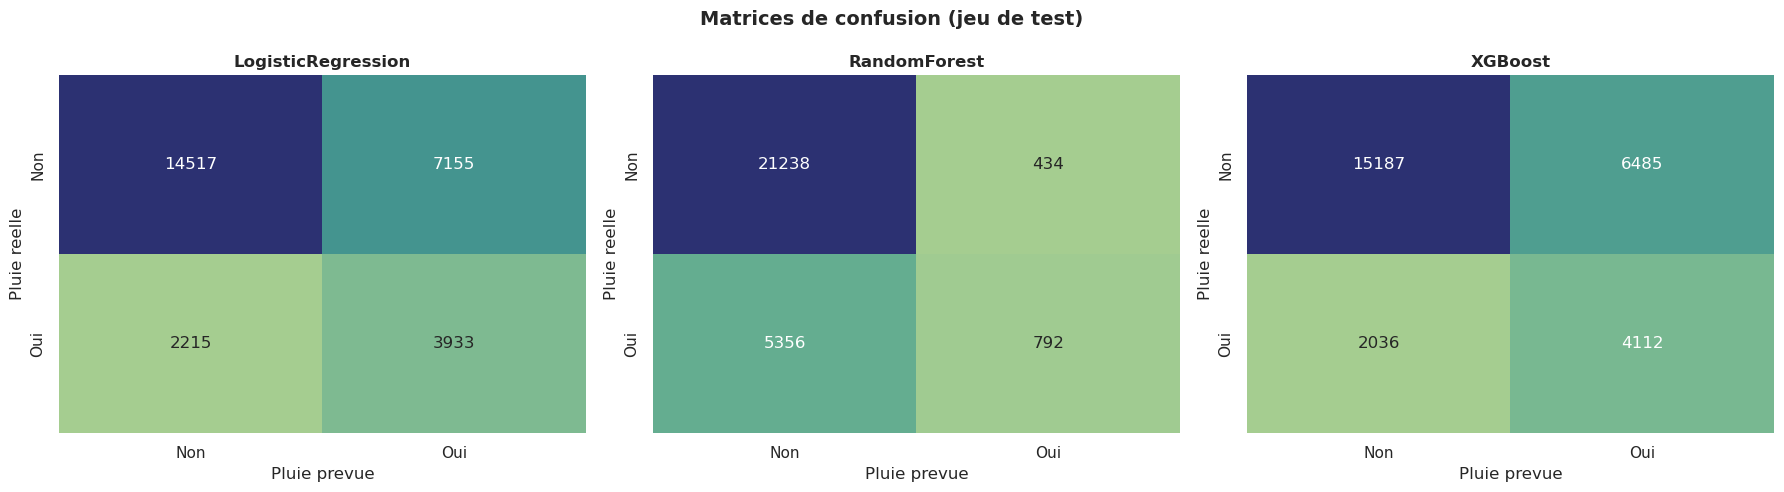

In [48]:
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nom in zip(axes, modeles):
    cm = confusion_matrix(y_test2, predictions[nom]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', cbar=False, ax=ax)
    ax.set_title(nom, fontsize=12, fontweight='bold')
    ax.set_xlabel("Pluie prevue")
    ax.set_ylabel("Pluie reelle")
    ax.set_xticklabels(['Non', 'Oui'])
    ax.set_yticklabels(['Non', 'Oui'])

fig.suptitle("Matrices de confusion (jeu de test)", fontsize=14, fontweight='bold')
plt.tight_layout()
# fig.savefig('../figures/etape3_01_matrices_confusion.png', dpi=150, bbox_inches='tight')
# print("Figure sauvegardee: figures/etape3_01_matrices_confusion.png")
plt.show()

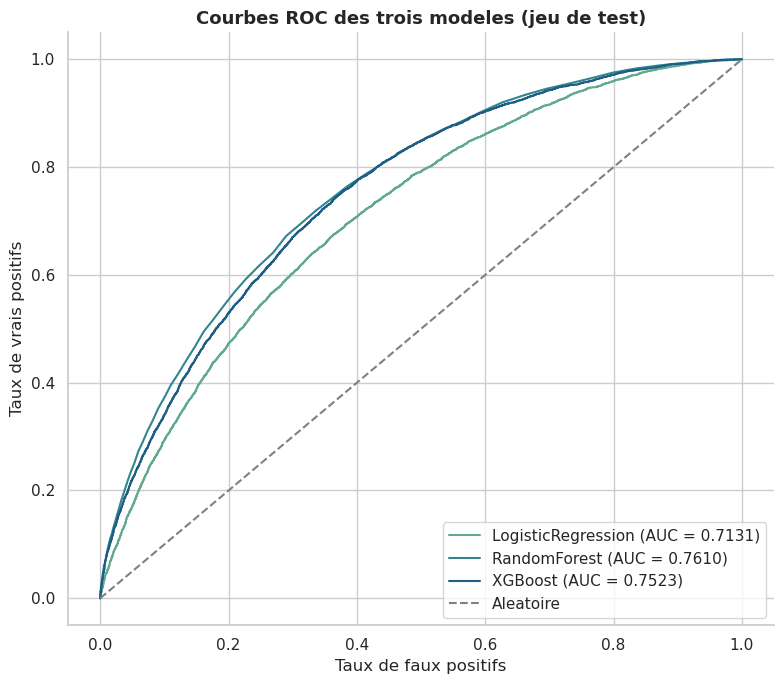

In [49]:
from sklearn.metrics import roc_curve

sns.set_theme(style="whitegrid", context="notebook")
couleurs = sns.color_palette("crest", len(modeles))

fig, ax = plt.subplots(figsize=(8, 7))
for nom, couleur in zip(modeles, couleurs):
    y_proba2 = predictions[nom]['y_proba']
    fpr, tpr, _ = roc_curve(y_test2, y_proba2)
    auc = roc_auc_score(y_test2, y_proba2)
    ax.plot(fpr, tpr, color=couleur, label=f"{nom} (AUC = {auc:.4f})")

# Ligne de reference du classifieur aleatoire
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatoire')
ax.set_title("Courbes ROC des trois modeles (jeu de test)", fontsize=13, fontweight='bold')
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
# fig.savefig('../figures/etape3_02_courbes_roc.png', dpi=150, bbox_inches='tight')
# print("Figure sauvegardee: figures/etape3_02_courbes_roc.png")
plt.show()

## Save model pour prediction a deux jours

In [50]:
# CELL 6: Sauvegarde des trois modeles entraines

import joblib
import os

# Recuperation des modeles entraines depuis le dictionnaire (CELL 2)
logreg = modeles['LogisticRegression']
rf = modeles['RandomForest']
xgb_model = modeles['XGBoost']

# Creation du dossier models/ a la racine du projet si necessaire
os.makedirs('../models', exist_ok=True)

# Sauvegarde : joblib pour les modeles sklearn, format natif JSON pour XGBoost
joblib.dump(logreg, '../models/logreg_2jours.joblib')
joblib.dump(rf, '../models/random_forest_2jours.joblib')
xgb_model.save_model('../models/xgboost_2jours.json')

print("Modeles sauvegardes:")
print(" - models/logreg_2jours.joblib")
print(" - models/random_forest_2jours.joblib")
print(" - models/xgboost_2jours.json")

Modeles sauvegardes:
 - models/logreg_2jours.joblib
 - models/random_forest_2jours.joblib
 - models/xgboost_2jours.json
